In [2]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [3]:
from tudatpy.interface import spice
from tudatpy.dynamics import environment_setup, parameters_setup, propagation_setup
from tudatpy import estimation
from tudatpy.estimation import observable_models_setup, estimation_analysis
from tudatpy.constants import GRAVITATIONAL_CONSTANT
from tudatpy.astro.frame_conversion import inertial_to_rsw_rotation_matrix
import matplotlib.gridspec as gridspec
from tudatpy.data.mpc import BatchMPC
from tudatpy.data.horizons import HorizonsQuery
from tudatpy.data.sbdb import SBDBquery
from tudatpy.estimation import observable_models, observations_setup, observations
from tudatpy import dynamics ## needed to get additional parameters to fit

# other useful modules
import numpy as np
import datetime
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from tudatpy.astro import time_representation
from tudatpy.astro.time_representation import DateTime
from astropy.table import Table
from tudatpy.astro import element_conversion    # for TU3 initial state

# additional things for the asteroids
from tudatpy import constants
import os           # for the extraction of asteroid kernels
from astroquery.jplhorizons import Horizons     # for extracting Cartesian coordinates

# SPICE KERNELS
spice.load_standard_kernels()

# Defining some constants

In [8]:
# Target 1998 TU3 (66146)
# target_mpc_code_list = [1566, 66146, 66391, 437844, 137924, 138127, 480883, 468468, 364136]
# target_mpc_code = [1566, 66146, 66391]
target_mpc_code = [1566]

observations_start = datetime.datetime(2001,1,1)
observations_end = datetime.datetime(2026, 1, 1)

# number of iterations for our estimation
# Change this depending on how long you want the convergence to run
number_of_pod_iterations = 6

# timestep of 20 hours for our estimation
timestep_global = 20 * 3600.0

# 2 month time buffer used to avoid interpolation errors:
time_buffer = 2 * 31 * 86400.0

# Define the frame origin and orientation
# This is useful for the large functions at the end
# However, I still define the frame orientation before then for my bodies
global_frame_origin = "SSB"
global_frame_orientation = "J2000"

include_minor_bodies = True

In [9]:
#target_sbdb = SBDBquery(target_mpc_code)
#
#mpc_codes = target_mpc_code  # the BatchMPC interface requires a list.
#target_spkid = target_sbdb.codes_300_spkid  # the ID used by Tudat
#obj = target_sbdb.query["object"]
#
## The ID used by Tudat (biggest asteroids have shortname, but smaller don't)
#target_name = (
#    obj.get("shortname") or
#    obj.get("fullname") or
#    obj.get("des")
#)  
#
#print(f"SPK ID for {target_name} is: {target_spkid}")

# Retrieving the observations

In [10]:

mpc_codes = target_mpc_code  # the BatchMPC interface requires a list.
batch = BatchMPC()
batch.get_observations(mpc_codes)
batch.filter(
    epoch_start = observations_start,
    epoch_end = observations_end,
)
print(batch.summary())

## Make sure wrapping is not an issue
batch.table["RA"] = (batch.table["RA"] + np.pi) % (2*np.pi) - np.pi


   Batch Summary:
1. Batch includes 1 minor planets:
   ['1566']
2. Batch includes 1129 observations, including 350 observations from space telescopes
3. The observations range from 81393038.16729331 to 808752696.4853065
   In seconds TDB since J2000: 81393038.16729331 to 808752696.4853065
   In Julian Days: 2452487.04831 to 2460905.562816
4. The batch contains observations from 51 observatories, including 2 space telescopes

None


In [11]:
epoch_start_nobuffer = DateTime.from_epoch(batch.epoch_start)
epoch_end_nobuffer =  DateTime.from_epoch(batch.epoch_end)

print(f"Epoch Start (no buffer): {epoch_start_nobuffer.to_epoch()}")
print(f"Epoch End (no buffer): {epoch_end_nobuffer.to_epoch()}")
print("--------------------------------------------------")
print(f"Epoch Start (no buffer): {epoch_start_nobuffer}")
print(f"Epoch End (no buffer): {epoch_end_nobuffer}")
print("--------------------------------------------------")


# This samples the cartesian state at 500 points over the observation time:
times_get_eph = np.linspace(epoch_start_nobuffer.to_epoch(), epoch_end_nobuffer.to_epoch(), 500)
epoch_start_buffer = epoch_start_nobuffer.to_epoch() - time_buffer
epoch_end_buffer = epoch_end_nobuffer.to_epoch() + time_buffer

print(f"Epoch Start (buffer): {DateTime.from_epoch(epoch_start_buffer)}")
print(f"Epoch End (buffer): {DateTime.from_epoch(epoch_end_buffer)}")
print()
print("Summary of space telescopes in batch:")
print(batch.observatories_table(only_space_telescopes=True))

Epoch Start (no buffer): 81393038.16729331
Epoch End (no buffer): 808752696.4853065
--------------------------------------------------
Epoch Start (no buffer): 2002-07-31 13:10:38.167293310165405
Epoch End (no buffer): 2025-08-18 01:31:36.485306501388550
--------------------------------------------------
Epoch Start (buffer): 2002-05-30 13:10:38.167293310165405
Epoch End (buffer): 2025-10-19 01:31:36.485306501388550

Summary of space telescopes in batch:
     Code  Name  count
1239  C51  WISE   33.0
1245  C57  TESS  317.0


# Set up the environment

In [12]:
# larger_bodies_to_create = [
#     "Sun",
#     "Mercury",
#     "Venus",
#     "Earth",
#     "Moon", ## DIFF
#     "Mars",
#     "Jupiter",
#     "Saturn",
#     "Uranus",
#     "Neptune",
# ]

larger_bodies_to_create = [
    "Sun",
    "Mercury",
    "Venus",
    "Earth",
    "Moon",
    "Mars",
    "Phobos",   # Mars
    "Deimos",   # Mars
    "Ceres",
    "Vesta",
    "Jupiter",
    "Io",       # Jupiter
    "Europa",   # Jupiter
    "Ganymede", # Jupiter
    "Callisto", # Jupiter
    "Saturn",
    "Titan",    # Saturn
    "Rhea",     # Saturn
    "Iapetus",  # Saturn
    "Dione",    # Saturn
    "Tethys",
    "Enceladus",
    "Mimas",
    "Uranus",
    "Neptune",
]

if include_minor_bodies:
    ## Ignore this for now
    smaller_bodies = {
        "Ceres": [1, 62.10], 
        "Pallas": [2, 13.73],
        "Juno": [3, 1.61],
        "Vesta": [4, 17.38],
        "Hebe": [6, 0.89],
        "Iris": [7, 0.73],
        "Flora": [8, 0.27],
        "Metis": [9, 0.44],
        "Hygiea": [10, 5.97],
        "Irene": [14, 0.25],
        "Eunomia": [15, 1.88],
        "Psyche": [16, 1.65],
        "Fortuna": [19, 0.42],
        "Thalia": [23, 0.15],
        "Amphitrite": [29, 0.98],
        "Daphne": [41, 0.56],
        "Europa": [52, 1.48],
        "Bamberga": [324, 0.71],
        "Davida": [511, 1.14],
        "Herculina": [532, 0.66],
        "Interamnia": [704, 2.65]
    }

In [14]:
# Many of the asteroids do not exist in the SPICE kernel
# Therefore I'm now adding them by downloading them in SPK files from the JPL Horizon website
# Then I will extract them with load_kernel

# ---------------------------------------------------------
# The path to the folder where the .bsp files are located
kernel_directory = "/home/emmabob/Bachelor_Project/asteroid_kernels/" 
# kernel_directory = "/home/balbinot/Bachelor_Project_Emma/asteroid_kernels/" 
print("Number of kernels:", spice.get_total_count_of_kernels_loaded())

if include_minor_bodies:
    # Loop through the dictionary and load the corresponding .bsp file
    for i, (name, data) in enumerate(smaller_bodies.items(), start=1):
        
        # Calculate the NAIF ID from the data list
        # E.g. Juno has 20000003 (ID: 3)
        ast_id = data[0]
        naif_id = 20000000 + ast_id
        
        # Then extract the ephemeris for each asteroid
        kernel_path = os.path.join(kernel_directory, f"{naif_id}.bsp")
        if os.path.exists(kernel_path):
            spice.load_kernel(kernel_path)
            print(f"{i}.Successfully loaded the kernel for {name} using file: {naif_id}.bsp")
        else:
            print(f"WARNING: Could not find {name}. Its kernel was not found at {kernel_path}. Make sure the file exists.")

Number of kernels: 13
1.Successfully loaded the kernel for Ceres using file: 20000001.bsp
2.Successfully loaded the kernel for Pallas using file: 20000002.bsp
3.Successfully loaded the kernel for Juno using file: 20000003.bsp
4.Successfully loaded the kernel for Vesta using file: 20000004.bsp
5.Successfully loaded the kernel for Hebe using file: 20000006.bsp
6.Successfully loaded the kernel for Iris using file: 20000007.bsp
7.Successfully loaded the kernel for Flora using file: 20000008.bsp
8.Successfully loaded the kernel for Metis using file: 20000009.bsp
9.Successfully loaded the kernel for Hygiea using file: 20000010.bsp
10.Successfully loaded the kernel for Irene using file: 20000014.bsp
11.Successfully loaded the kernel for Eunomia using file: 20000015.bsp
12.Successfully loaded the kernel for Psyche using file: 20000016.bsp
13.Successfully loaded the kernel for Fortuna using file: 20000019.bsp
14.Successfully loaded the kernel for Thalia using file: 20000023.bsp
15.Successfully 

In [15]:
asteroid_id_list = [str(i_ast) for i_ast in target_mpc_code]

smaller_bodies_list = []
if include_minor_bodies:
    smaller_bodies_list = list(smaller_bodies.keys())

bodies_to_create = larger_bodies_to_create + smaller_bodies_list + asteroid_id_list
bodies_to_propagate = asteroid_id_list     # I only propagate TU3, I pull the other values from pre-existing ephemeris

# ----------------------------
# Create bodies in simulation.
# Pull on the data already known for the larger bodies
body_settings = environment_setup.get_default_body_settings(
    bodies = larger_bodies_to_create, 
    base_frame_origin = 'SSB',                   # Correct as initial conditions from JPL are in SSB
    base_frame_orientation = 'J2000')       # Intiial conditions from JPL are in J2000


# Add a buffer time
buffer_time = 5 * constants.JULIAN_DAY

if include_minor_bodies:
    # A for loop to extract and add settings for the 21 massive asteroids from JPL Horizon
    for i, (name, data) in enumerate(smaller_bodies.items(), start=1):
    
        # Extract asteroid properties
        ast_id = data[0]
        ast_mu = data[1] * 1e9  # Convert km^3/s^2 to m^3/s^2 (SI-units); reduced mass
    
        # Calculate the SPICE NAIF ID (2000000 + minor planet number) again
        naif_id = 20000000 + ast_id
    
        try:
            
            # To fix Tudat finding the data:
            naif_id_str = str(2000000 + ast_id)
    
            # Instead try extracting the ephemeris from SPICE (w. direct_spice) 
            DIRECT_ephemeris_settings_ast = environment_setup.ephemeris.direct_spice(
                frame_origin = 'SSB',                    # The SPK files were w.r.t the Sun
                frame_orientation = 'J2000',        # tells Tudat the asteroids' coordinates are wrt ECLIPJ2000 
                body_name_to_use = naif_id_str)
    
            # Create empty slots, then insert the asteroids
            body_settings.add_empty_settings(name)
            # Assign ephemeris
            body_settings.get(name).ephemeris_settings = DIRECT_ephemeris_settings_ast
    
            # Assign gravity field (w. the central function that manually adds the mu)
            body_settings.get(name).gravity_field_settings = (
                environment_setup.gravity_field.central(ast_mu)
            )
    
            print(f" {i}. Successfully configured {name} (ID: {ast_id} / NAIF: {naif_id})")
    
        except Exception as e:
            print(f"Could not fetch data for {name}: {e}")


## NOTE EB: I removed this without any impact on the rest of the code
## NOTE: body_settings does not include the members in target_mpc_list
# Manually add empty settings for 9 asteroids
#for name in asteroid_id_list:
#    body_settings.add_empty_settings(name)


 1. Successfully configured Ceres (ID: 1 / NAIF: 20000001)
 2. Successfully configured Pallas (ID: 2 / NAIF: 20000002)
 3. Successfully configured Juno (ID: 3 / NAIF: 20000003)
 4. Successfully configured Vesta (ID: 4 / NAIF: 20000004)
 5. Successfully configured Hebe (ID: 6 / NAIF: 20000006)
 6. Successfully configured Iris (ID: 7 / NAIF: 20000007)
 7. Successfully configured Flora (ID: 8 / NAIF: 20000008)
 8. Successfully configured Metis (ID: 9 / NAIF: 20000009)
 9. Successfully configured Hygiea (ID: 10 / NAIF: 20000010)
 10. Successfully configured Irene (ID: 14 / NAIF: 20000014)
 11. Successfully configured Eunomia (ID: 15 / NAIF: 20000015)
 12. Successfully configured Psyche (ID: 16 / NAIF: 20000016)
 13. Successfully configured Fortuna (ID: 19 / NAIF: 20000019)
 14. Successfully configured Thalia (ID: 23 / NAIF: 20000023)
 15. Successfully configured Amphitrite (ID: 29 / NAIF: 20000029)
 16. Successfully configured Daphne (ID: 41 / NAIF: 20000041)
 17. Successfully configured E

In [16]:
# Define the solar quadrupole moment
# See Book by Montenbruck and Gill, pg 57-58 for the conversion/ equations
# To understand function see: https://py.api.tudat.space/en/latest/dynamics/environment_setup/gravity_field.html#tudatpy.dynamics.environment_setup.gravity_field.spherical_harmonic
# For the Sun's gravitational potential, Sn0 is zero by definition

J_2 = 2.2 * 10**(-7)
norm_C_20 = - J_2 / np.sqrt(5)

norm_cosine_coeffs = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [norm_C_20, 0.0, 0.0]
])

norm_sine_coeffs = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0]
])

# Technically I've defined this below as well
mu_Sun = 1.327124400420322e+20
radius_Sun = 695.99 * 10**6         # ± 0.07 * 10**6 m

body_settings.get("Sun").gravity_field_settings = (
    environment_setup.gravity_field.spherical_harmonic(
        gravitational_parameter = mu_Sun,
        reference_radius = radius_Sun,
        normalized_cosine_coefficients = norm_cosine_coeffs,
        normalized_sine_coefficients = norm_sine_coeffs,
        # Ensure Tudat knows that the values are defined in the Sun's fixed frame
        # The International Astronomical Union (IAU) defines standard body-fixed frames for well-known bodies
        associated_reference_frame = "IAU_Sun"      # Ensures that the buldge rotates with the body
    )
)

bodies = environment_setup.create_system_of_bodies(body_settings) ## Define this here too since observations need it?
bodies_to_propagate = batch.MPC_objects
central_bodies = ["SSB"] * len(batch.MPC_objects)

In [17]:
# Transform the MPC observations into a tudat compatible format.
# note that we explicitly exclude all satellite observations in this step by setting included satellites to None.
observation_collection = batch.to_tudat(bodies=bodies, included_satellites=None,
                                        apply_star_catalog_debias=True, apply_weights_VFCC17=True,)

# set create angular_position settings for each link in the list.
observation_settings_list = list()
link_list = list(
    observation_collection.get_link_definitions_for_observables(
        observable_type=observable_models_setup.model_settings.angular_position_type
    )
)

for link in link_list:
    # add optional bias settings here
    observation_settings_list.append(
        observable_models_setup.model_settings.angular_position(link, bias_settings=None)
    )

/home/emmabob/Bachelor_Project/tudat-dev/.pixi/envs/default/lib/python3.14/site-packages/tudatpy/data/mpc/mpc.py:140: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bias_dataframe[["aa", "bb", "cc", "dd"]] = unknown_columns
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function s

In [18]:
initial_guess_list = []

for i_horizon in asteroid_id_list:
    print(i_horizon)
    obj = HorizonsQuery(
        query_id=i_horizon,
        location="@0",
        epoch_list=[epoch_start_buffer],
    )

    initial_guess = obj.cartesian(frame_orientation='J2000',
                aberations='geometric')

    initial_guess = initial_guess[0][1:]    # unpack and remvoe the first component (that is time)
    initial_guess_list.append(initial_guess)

# To make the initial guess into (N*6,) instead of (N, 6) (where N is the amount of asteroid estimated for)
# This makes the initial guess into one long array
initial_guess = np.concatenate(initial_guess_list)


1566


In [19]:
# initial_guess - initial_guess_spice

In [20]:
times_get_eph = np.linspace(epoch_start_nobuffer.to_epoch(), epoch_end_nobuffer.to_epoch(), 500)
epoch_start_buffer = epoch_start_nobuffer.to_epoch() - time_buffer
epoch_end_buffer = epoch_end_nobuffer.to_epoch() + time_buffer

print("The initial state for 1998-TU3 (20066146) in SPICE at epoch_start (w a buffer):")
print(epoch_start_buffer, initial_guess)

The initial state for 1998-TU3 (20066146) in SPICE at epoch_start (w a buffer):
76036238.16729331 [ 1.18500358e+11 -2.19804247e+11 -1.53724608e+11  8.30750987e+03
  3.11933632e+03 -2.42827701e+03]


In [21]:
# # For TU3 the value of A2 is computed 

# avg_a_TU3_greenberg = -5.60 * 10**(-4)                       # AU / Myr 
# avg_a_TU3_calc = -5.60 * 10**(-4) / (10**6 * 365)            # AU / days
# uncertain_avg_a_TU3_greenberg = 3.9 * 10**(-4)               # AU / Mry
# uncertain_avg_a_TU3_calc = 3.9 * 10**(-4) / (10**6 * 365)    # AU / days

# a_TU3_calc = 0.7875484323220899 # AU
# e_TU3_calc = 0.4836694929440215 # unitless
# n_TU3_calc = 1.410224212386279  # degrees/ days (remember that angles are unitless in unit conversion)

# A_2_TU3_AUdays2 = avg_a_TU3_calc * (n_TU3_calc * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2
# A_2_TU3_uncertainty_AUdays2 = uncertain_avg_a_TU3_calc * (n_TU3_calc * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2

# print(f"The Yarkovksy parameter for TU3: {A_2_TU3_AUdays2} AU / days^2")
# print(A_2_TU3_uncertainty_AUdays2)

# # Units from AU/days2 to m/s2
# A_2_TU3_ms2 = A_2_TU3_AUdays2 * 149597870691 / ((24 * 3600)**2)
# print(A_2_TU3_ms2)

In [22]:
# The Yarkovksy Parameters for 8 out of 9 asteroids
# They were calculated in the file Table_of_Asteroids/test_Table_Code.ipynb
# The 6th asteroid, (138127) 2000 EE14 does not have a value in literature and is therefore set to zero
# However, it does have an uncertainty

A_2_ast_ms2 = np.array([-7.4947047935106e-14, -1.79655733799732e-13, -1.1402599897661214e-13, 8.080665194434216e-13, -2.3011625098947506e-13, 0.0, -1.3698663069299618e-12, -1.3118190748109315e-12, -6.383317087378818e-13])

In [23]:
acceleration_dict3_insideloop = {}

for asteroid_name, A2_ast in zip(target_mpc_code, A_2_ast_ms2):

    accelerations_LVL3 = {

        "Sun": [
            propagation_setup.acceleration.spherical_harmonic_gravity(2, 0),
            propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True),
            propagation_setup.acceleration.yarkovsky(A2_ast),
        ],

        "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
        "Venus": [propagation_setup.acceleration.point_mass_gravity()],
        "Earth": [propagation_setup.acceleration.spherical_harmonic_gravity(2, 2)],
        "Moon": [propagation_setup.acceleration.point_mass_gravity()],
        "Mars": [propagation_setup.acceleration.point_mass_gravity()],
        "Phobos": [propagation_setup.acceleration.point_mass_gravity()],
        "Deimos": [propagation_setup.acceleration.point_mass_gravity()],

        "Ceres": [propagation_setup.acceleration.point_mass_gravity()],
        "Vesta": [propagation_setup.acceleration.point_mass_gravity()],

        "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
        "Io": [propagation_setup.acceleration.point_mass_gravity()],
        "Europa": [propagation_setup.acceleration.point_mass_gravity()],
        "Ganymede": [propagation_setup.acceleration.point_mass_gravity()],
        "Callisto": [propagation_setup.acceleration.point_mass_gravity()],

        "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
        "Titan": [propagation_setup.acceleration.point_mass_gravity()],
        "Rhea": [propagation_setup.acceleration.point_mass_gravity()],
        "Iapetus": [propagation_setup.acceleration.point_mass_gravity()],
        "Dione": [propagation_setup.acceleration.point_mass_gravity()],
        "Tethys": [propagation_setup.acceleration.point_mass_gravity()],
        "Enceladus": [propagation_setup.acceleration.point_mass_gravity()],
        "Mimas": [propagation_setup.acceleration.point_mass_gravity()],

        "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
        "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
    }

    if include_minor_bodies:

        accelerations_LVL3.update({
            perturber: [
                propagation_setup.acceleration.point_mass_gravity()
            ]
            for perturber in smaller_bodies_list
        })

    acceleration_dict3_insideloop[str(asteroid_name)] = accelerations_LVL3

# # Finally, define the acceleration for TU3
# # Because only TU3 is propagated
# acceleration_dict3 = {b: accelerations_merged_LVL3 for b in bodies_to_propagate}
acceleration_dict3 = acceleration_dict3_insideloop

In [24]:
acceleration_dict3

{'1566': {'Sun': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.SphericalHarmonicAccelerationSettings at 0x7aad8a750c70>,
  'Mercury': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x7aad4a50fef0>],
  'Venus': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x7aad4a50eab0>],
  'Earth': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.SphericalHarmonicAccelerationSettings at 0x7aad4a50f770>],
  'Moon': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x7aad4a534a70>],
  'Mars': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x7aad4a535eb0>],
  'Phobos': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x7aad4a535ef0>],
  'Deimos': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x7aad4a536370>],
  'Ceres': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.Acceleratio

In [25]:
# Thus, the environment becomes:
# In other of my files this is body_system
# However to be compatible with Tudat example, here it's called bodies
#bodies = environment_setup.create_system_of_bodies(body_settings)

In [26]:
# Create numerical integrator settings
integrator_settings = propagation_setup.integrator.runge_kutta_variable_step_size(
    timestep_global,
    propagation_setup.integrator.CoefficientSets.rkf_78,
    timestep_global,
    timestep_global,
    1.0,
    1.0,
)
# Terminate at the time of oldest observation
termination_condition = propagation_setup.propagator.time_termination(epoch_end_buffer)

In [27]:
# Create the acceleration models.
acceleration_models = propagation_setup.create_acceleration_models(
    bodies, acceleration_dict3, bodies_to_propagate, central_bodies
)

In [28]:
print(central_bodies, acceleration_models, bodies_to_propagate)

['SSB'] {'1566': {'Vesta': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7aad8a610870>], 'Venus': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7aad8a6112b0>], 'Uranus': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7aad8a611e30>], 'Titan': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7aad8a612fb0>], 'Thalia': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7aad8a6126f0>], 'Saturn': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7aad8a613fb0>], 'Psyche': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7aad8a6100f0>], 'Phobos': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7aad8a6127b0>], 'Tethys': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7aad8a610ab0>], 'Europa': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7aad8a613b30>], 'Jupiter': [<tudatpy.kernel.dynamics.propagat

In [29]:
# Create propagation settings
propagator_settings = propagation_setup.propagator.translational(
    central_bodies=central_bodies,
    acceleration_models=acceleration_models,
    bodies_to_integrate=bodies_to_propagate,
    initial_states=initial_guess,
    initial_time=epoch_start_buffer,
    integrator_settings=integrator_settings,
    termination_settings=termination_condition,
)

In [30]:
# Initial state
parameter_settings = parameters_setup.initial_states(
    propagator_settings, bodies
)

# The Yarkovsky Effect for all the observed asteroids
for i, ID in enumerate(target_mpc_code):
    # if ID = 
    parameter_settings.append(dynamics.parameters_setup.yarkovsky_parameter(f"{target_mpc_code[i]}"))

## J2 and Beta
parameter_settings.append(dynamics.parameters_setup.spherical_harmonics_c_coefficients_block("Sun", [(2,0)])) ##Indicate the indices of the free parameters in your C matrix for SPERICAL HARMONICS
parameter_settings.append(dynamics.parameters_setup.ppn_parameter_beta())

# Create the parameters that will be estimated
parameters_to_estimate = parameters_setup.create_parameter_set(
    parameter_settings, bodies, propagator_settings
)

Warning when creating estimated parameters. The parameters will be ordered such that all parameters (excluding initial states) defined by a single variable will be stored before those represented by a list of variables. The parameter order will be different than those in your parameter settings. It is recommended that you check the parameter order by calling the print_parameter_names(Python)/printEstimatableParameterEntries(C++) function


In [31]:
# Set up the estimator
estimator = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

# provide the observation collection as input, and limit number of iterations for estimation.
pod_input = estimation_analysis.EstimationInput(
    observations_and_times = observation_collection,
    convergence_checker = estimation_analysis.estimation_convergence_checker(
        maximum_iterations = number_of_pod_iterations,
    ),
)

# to_tudat() applies weights to a set of observations between an observatory and the target.
# the method below tells tudat to use the weights applied to these sets.
# This step is required when setting weights through the BatchMPC class.
if True:
    pod_input.set_weights_from_observation_collection()
    
# Set methodological options
pod_input.define_estimation_settings(reintegrate_variational_equations=True)

# Perform the estimation
pod_output = estimator.perform_estimation(pod_input)


# we store the following outputs for plotting and analysis.
#return pod_output, batch_temp, observations, estimator

Calculating residuals and partials 1558
Current residual: 5.09678e-05
Parameter update   -74685.7    -72133.8     66739.4  0.00554323 -0.00496247 0.000904444  1.1934e-12   -0.121995 1.02732e-06
Calculating residuals and partials 1558
Current residual: 2.903e-06
Parameter update     188.766      94.7957     -7.27106 -1.55174e-07 -7.68896e-06 -3.41451e-06 -1.37802e-16  0.000461605 -6.48508e-09
Calculating residuals and partials 1558
Current residual: 2.90306e-06
Parameter update  0.00661488   0.00506527  -0.00593589  1.58347e-10  4.81525e-10  1.35939e-10 -4.82519e-19 -8.97432e-09  2.76679e-13
Calculating residuals and partials 1558
Current residual: 2.90306e-06
Parameter update   0.0625214    0.0133355   -0.0208893 -3.81233e-09  7.66381e-09  5.07914e-09 -1.77978e-19  7.83971e-09 -3.30052e-13
Calculating residuals and partials 1558
Current residual: 2.90306e-06
Parameter update  -0.0620195   -0.0156784    0.0203484  3.49283e-09 -7.85565e-09 -5.18142e-09  5.44538e-19 -1.50497e-08  9.13041e

setWeightsFromObservationCollection is deprecated: the weightsMatrixDiagonals_ vector is now by default defined by the weights stored in the ObservationCollection object. (see https://docs.tudat.space/en/latest/user-guide/state-estimation/observation-simulation/observation-collection-manipulation/modifying-collections.html#setting-weights).


In [32]:
## Get best-fit states at the same times as ephemeris of Horizons etc
state_estimates = {}
for asteroid_id in target_mpc_code:
    state_estimates[asteroid_id] = np.array(
        [
            bodies.get(str(asteroid_id)).ephemeris.cartesian_state(timee) for timee in times_get_eph
        ]
    )

In [33]:
#residual_history.shape (2*N, number_iterations)
#residual_history format is [RA_0, Dec_0, RA_1, Dec_1, ..., RA_N, Dec_N) where N is the number of observations
residual_history = pod_output.residual_history
residual_times = np.array(observation_collection.concatenated_times) / (86400 * 365.25) + 2000

In [34]:
residual_times[::2]

array([2015.47816963, 2015.47817571, 2015.47818398, 2015.47819093,
       2015.47819931, 2015.47248155, 2015.47249067, 2015.47250105,
       2015.47251014, 2015.47251925, 2015.47252963, 2015.47253869,
       2015.47254776, 2015.47255816, 2015.47256722, 2015.47257631,
       2015.4725854 , 2015.47259578, 2015.47260355, 2015.47261481,
       2015.47262389, 2015.47263296, 2015.47264202, 2015.4726524 ,
       2015.47266146, 2015.47267186, 2015.47268092, 2015.47269001,
       2015.47270036, 2015.47270943, 2015.47271849, 2015.47272755,
       2015.47516101, 2015.4751791 , 2015.47519723, 2015.47521667,
       2015.47523613, 2015.47525585, 2015.47527427, 2015.47529242,
       2015.47533127, 2015.47534945, 2015.47536892, 2015.47538838,
       2015.47540654, 2015.47542592, 2015.47544541, 2015.47545601,
       2015.47547442, 2015.47547904, 2015.47548135, 2015.47548366,
       2015.47548598, 2015.47548829, 2015.4754906 , 2015.47549292,
       2015.47549523, 2015.46721801, 2015.46722217, 2015.46722

In [35]:
RA_residual_0 = residual_history[::2, 0] ## 0th iteration
Dec_residual_0 = residual_history[1::2, 0] ## 0th iteration
RA_residual_final = residual_history[::2, -1] ## final iteration
Dec_residual_final = residual_history[1::2, -1] ## final iteration

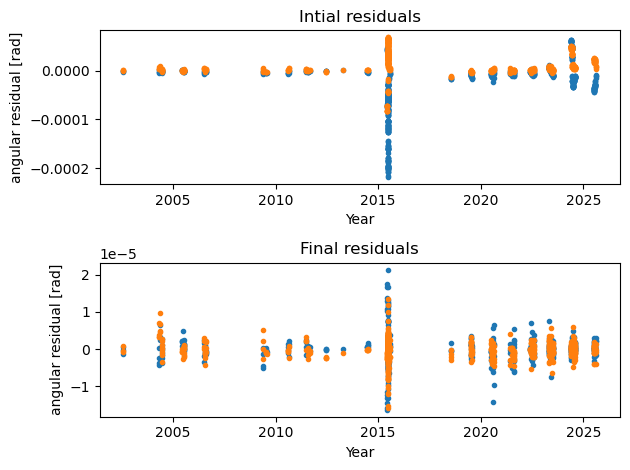

In [36]:
subplot(211)
plot(residual_times[::2], RA_residual_0, '.', label='RA')
plot(residual_times[1::2], Dec_residual_0, '.', label='RA')
xlabel('Year')
ylabel("angular residual [rad]")
title('Intial residuals')

subplot(212)
plot(residual_times[::2], RA_residual_final, '.', label='RA')
plot(residual_times[1::2], Dec_residual_final, '.', label='RA')
xlabel('Year')
ylabel("angular residual [rad]")
title('Final residuals')
     
tight_layout()

In [37]:
reference_states_i = []
index_list = []

print(target_mpc_code)

for i, ast_name in enumerate(target_mpc_code):    
    print(i, ast_name)
    horizonq = HorizonsQuery(
                query_id=f"{ast_name};",
                location=f"500@{global_frame_origin}",
                epoch_list=list(times_get_eph),
                extended_query=True,
            )

    ref = horizonq.cartesian(
                frame_orientation=global_frame_orientation,
                aberations='geometric'
            )[:, 1:]
    
    index_list.append(i)
    reference_states_i.append(ref)

[1566]
0 1566


In [38]:
# first_perihelion_in_years = np.array(18774000.0 / (365.25 * 24 * 3600))

# plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='A perihelion passage')

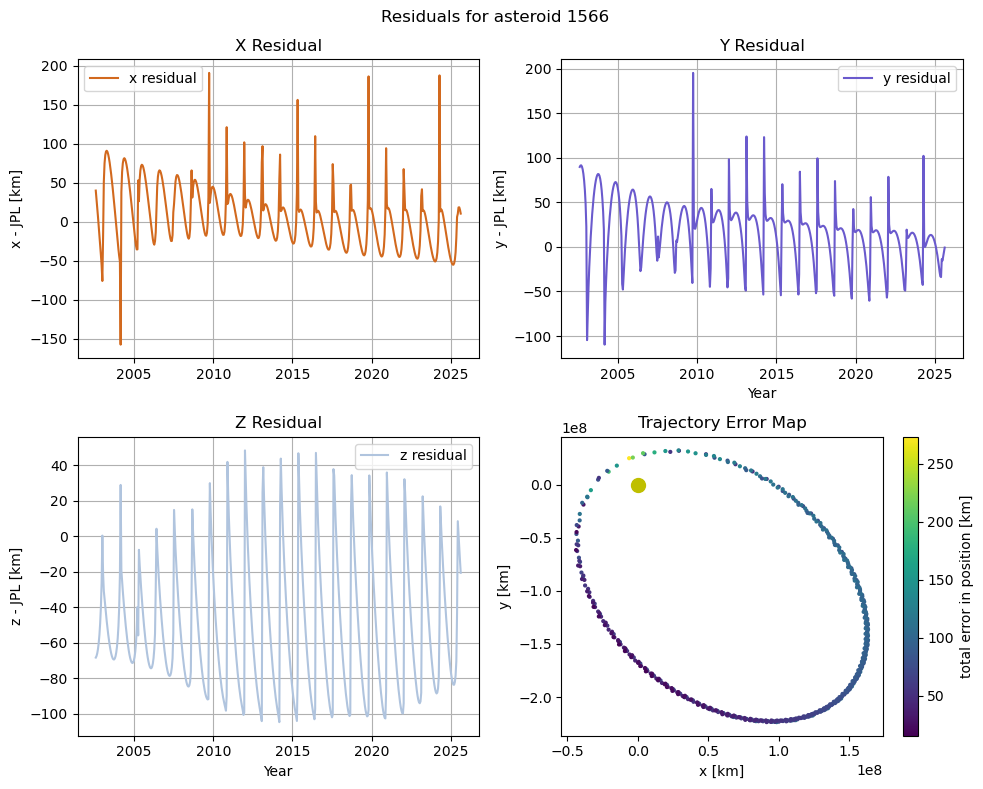

In [39]:
for i, ref_state in zip(index_list, reference_states_i):

    times_plot = times_get_eph / (86400 * 365.25) + 2000

    error_to_reference_i = (
        reference_states_i[i]
        - np.array(state_estimates[target_mpc_code[i]])
    ) / 1000  # km

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    # X residual
    axs[0, 0].plot(
        times_plot,
        error_to_reference_i[:, 0],
        color='chocolate',
        label='x residual'
    )
    axs[0, 0].set_title('X Residual')
    axs[0, 0].set_ylabel('x - JPL [km]')
    axs[0, 0].legend()
    axs[0, 0].grid()

    # Y residual
    axs[0, 1].plot(
        times_plot,
        error_to_reference_i[:, 1],
        color='slateblue',
        label='y residual'
    )
    axs[0, 1].set_title('Y Residual')
    axs[0, 1].set_ylabel('y - JPL [km]')
    axs[0, 1].set_xlabel('Year')
    axs[0, 1].legend()
    axs[0, 1].grid()

    # Z residual
    axs[1, 0].plot(
        times_plot,
        error_to_reference_i[:, 2],
        color='lightsteelblue',
        label='z residual'
    )
    axs[1, 0].set_title('Z Residual')
    axs[1, 0].set_ylabel('z - JPL [km]')
    axs[1, 0].set_xlabel('Year')
    axs[1, 0].legend()
    axs[1, 0].grid()

    # XY trajectory colored by total position error
    ee = state_estimates[target_mpc_code[i]]

    sc = axs[1, 1].scatter(
        ee[:, 0] / 1000,
        ee[:, 1] / 1000,
        c=np.linalg.norm(error_to_reference_i, axis=1),
        s=4
    )

    axs[1, 1].plot(0, 0, 'yo', ms=10)
    axs[1, 1].set_title('Trajectory Error Map')
    axs[1, 1].set_xlabel('x [km]')
    axs[1, 1].set_ylabel('y [km]')

    cb = fig.colorbar(sc, ax=axs[1, 1])
    cb.set_label('total error in position [km]')

    fig.suptitle(f'Residuals for asteroid {target_mpc_code[i]}')

    plt.tight_layout()
    plt.show()

In [40]:
# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input = estimation_analysis.CovarianceAnalysisInput(observation_collection)
covariance_output = estimator.compute_covariance(covariance_input)

correlations = covariance_output.correlations

Calculating residuals and partials 1558


In [41]:
# Create a function to generate the axes of the covariance matrix

def build_estimated_param_names(mpc_target_asteroid):
    base_names = ["x", "y", "z", "vx", "vy", "vz"]

    estimated_param_names = []

    # repeat state block for each asteroid
    for i, ID_i in enumerate(mpc_target_asteroid, start=1):
        state_block = [f"{name}_{ID_i}" for name in base_names]
        estimated_param_names.extend(state_block)

    # add global parameters (only once)
    estimated_param_names += [f"A_2_{i}" for i in mpc_target_asteroid]

    # add global parameters (only once)
    estimated_param_names += ["J2", "Beta-1"]

    return estimated_param_names


estimated_param_names = build_estimated_param_names(target_mpc_code)

print(estimated_param_names)

['x_1566', 'y_1566', 'z_1566', 'vx_1566', 'vy_1566', 'vz_1566', 'A_2_1566', 'J2', 'Beta-1']


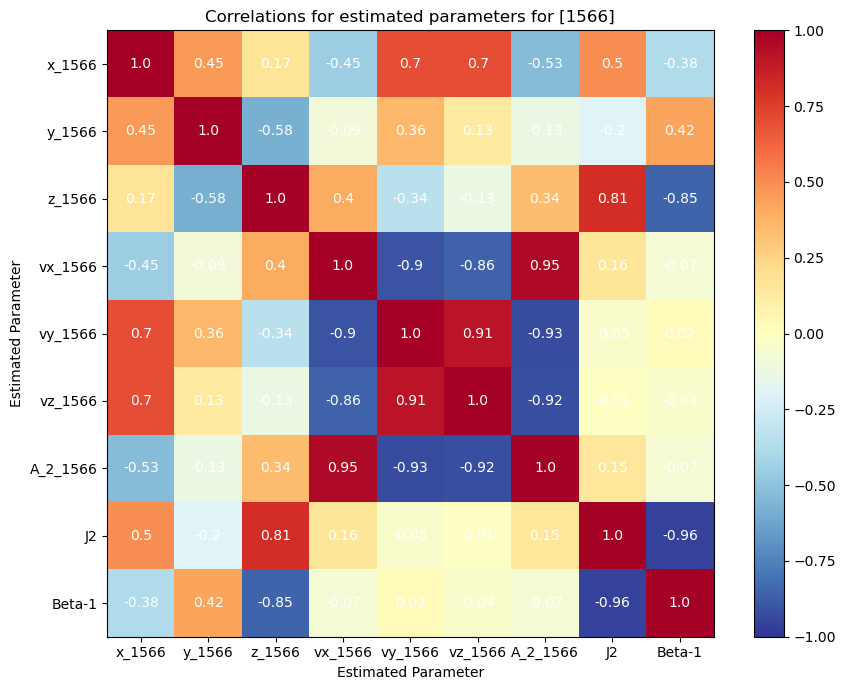

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

im = ax.imshow(correlations, cmap=cm.RdYlBu_r, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)
ax.set_yticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)

# add numbers to each of the boxes
for i in range(len(estimated_param_names)):
    for j in range(len(estimated_param_names)):
        text = ax.text(
            j, i, round(correlations[i, j], 2), ha="center", va="center", color="w"
        )

cb = plt.colorbar(im)

ax.set_title(f"Correlations for estimated parameters for {target_mpc_code}")
ax.set_xlabel("Estimated Parameter")
ax.set_ylabel("Estimated Parameter")

#fig.suptitle(f"Correlations for estimated parameters for {target_name}")

fig.set_tight_layout(True)

In [43]:
print(len(correlations))
print(correlations.size)
# print(correlations)
print(covariance_output.formal_errors)
print(covariance_output.weighted_design_matrix)

9
81
[5.83747257e+04 3.60557397e+04 4.92079501e+04 3.69939512e-03
 6.06634705e-03 4.47469069e-03 1.41431662e-13 2.45028362e-01
 1.18256926e-05]
[[-1.75775229e-04  3.24156442e-04  2.30151366e-04 ... -4.43112482e+12
  -2.20280434e+00 -2.14741334e+04]
 [ 1.04100720e-04 -1.92987603e-04 -1.30529783e-04 ...  2.60392433e+12
   1.91696232e+00  4.33415921e+04]
 [-1.75730752e-04  3.24075104e-04  2.30093637e-04 ... -4.43001138e+12
  -2.20239444e+00 -2.14709237e+04]
 ...
 [ 3.38476894e-06 -5.80530129e-06 -2.28897546e-06 ...  1.16073324e+11
   7.43311823e-02  9.95580949e+03]
 [-9.92030670e-06  2.20812617e-05  1.46014686e-05 ... -4.94209099e+11
  -1.61072451e+00 -2.98584406e+04]
 [ 3.38405455e-06 -5.80401207e-06 -2.28802565e-06 ...  1.16043865e+11
   7.43370654e-02  9.95613668e+03]]


In [44]:
1 / ((0.1 / (3600))**2)

1295999999.9999998

# Manually adding stellar occultations

Note: I begin by adding simulated stellar occultations for one asteroid. These steps are shown in depth. Then I merge this simulated stellar occultation with the data from MPC. 
I examine each uncertainty by hand and then I add them to a personal file, this is how I will create the list at the bottom to compare errors.

I begin by examining stellar occultations of one asteroid, and then test what the difference is if I add several occultations at different times for that asteroid.
Further down I also experiment how the uncertainties on beta and J2 change when I add one occultation for several asteroids.

### Adding the first asteroid (for stellar occultations)

In [45]:
# Step 0 of Stellar Occult.: Add a ground station
# I am following the Covariance Analysis with DELFI-C3 and add the observer in Delft, Netherlands

# Define the position of the ground station on Earth
station_altitude = 0.0
delft_latitude = np.deg2rad(52.00667)
delft_longitude = np.deg2rad(4.35556)

# Add the ground station to the environment
environment_setup.add_ground_station(
    bodies.get_body("Earth"),
    "TrackingStation",              # Important, name it correctly
    [station_altitude, delft_latitude, delft_longitude],
    element_conversion.geodetic_position_type)

In [46]:
# 1. Create the links and receiver/ transmitters

from tudatpy.estimation.observations_setup import observations_simulation_settings
from tudatpy.estimation.observable_models_setup import links
# from tudatpy.estimation.observable_models_setup import model_settings
from tudatpy.astro.time_representation import Time

one_way_tracking_ast_link_ends = dict()
one_way_tracking_ast_link_ends[links.transmitter] = links.body_origin_link_end_id("1566")
one_way_tracking_ast_link_ends[links.receiver] = links.body_reference_point_link_end_id("Earth", "TrackingStation")
one_way_tracking_ast_link_definition = links.link_definition(one_way_tracking_ast_link_ends)

# # 0 is at J2000
# time_1 = 10
# # Ten years after
# time_2 = 10 * 365.25 * 24 * 3600
# # Twenty years after
# time_3 = 20 * 365.25 * 24 * 3600

# Because my observations start on the 1st of Jan 2001
one_year_seconds = 365.25 * 24 * 3600 
time_1 = 3 * one_year_seconds + 10
time_2 = 10 * one_year_seconds + 10
time_3 = 15 * one_year_seconds + 10
time_4 = 15 * one_year_seconds + 5 * 24 * 3600
time_5 = 24 * one_year_seconds + 10

# observation_times = [time_1, time_2, time_3]
observation_times = [time_1, time_2, time_3, time_4, time_5]

In [47]:
# 2. Create an observation model settings
# (Needed for observation_simulators)
# Defines WHAT is actually observed/ measured

occultation_observation_settings_list = [
    observable_models_setup.model_settings.angular_position(
        one_way_tracking_ast_link_definition
    )
]

type(occultation_observation_settings_list[0])

tudatpy.kernel.estimation.observable_models_setup.model_settings.ObservationModelSettings

In [48]:
# 3. Create the observation simulator objects (with the function create_observation_simulators()
# Tells the code HOW to compute the observable numerically

# (Needed for observation_simulators)

observation_simulators = observations_simulation_settings.create_observation_simulators(occultation_observation_settings_list, bodies)

In [49]:
# 3.75 .
# Moved this down
# WHEN and HOW the measuremenets are taken

# Define the observable_type to be angular for stellar occultations
# I define the observation to be that of an angular_position (since the measurements are made in RA and DEC)
occultation_observable_type = observable_models_setup.model_settings.angular_position_type


observation_simulation_settings = observations_simulation_settings.tabulated_simulation_settings(
    occultation_observable_type,
    one_way_tracking_ast_link_definition,
    observation_times,
    reference_link_end_type=links.receiver      # is this receiver or transmitter?
)

In [50]:
# 2. Add noise to the data

# 1. Define noise level (using the dominant uncertainty for the scalar definition)
sigma_dec_mili_arcsec = 1.0 
sigma_noise_rad = np.deg2rad(sigma_dec_mili_arcsec / (3600.0 * 1000.0))    #Make an explicit float scalar

# 2. Inject the noise 
# Note: This code adds noise to observation_simulation_settings
observations_setup.random_noise.add_gaussian_noise_to_observable(
    [observation_simulation_settings],
    sigma_noise_rad,                  # Passed as a single float scalar
    occultation_observable_type
)

In [51]:
print(
    bodies.get_body("1566")
          .ephemeris
)

print(epoch_start_buffer)
print(epoch_end_buffer)
print(epoch_start_nobuffer)
print(epoch_end_nobuffer)

76036238.16729331
814109496.4853065
2002-07-31 13:10:38.167293310165405
2025-08-18 01:31:36.485306501388550


In [52]:
# 4. Simulate the observations

from tudatpy.estimation.observations_setup.observations_wrapper import simulate_observations

simulated_observations = simulate_observations(
    [observation_simulation_settings],
    observation_simulators,
    bodies
)


In [53]:
# 5. Add the weights (I've chosen to add constant weights to any stellar occultation I simulate)

In [54]:
weight1 = 1.0 / (sigma_noise_rad ** 2)
weight2 = 1.0 / (sigma_noise_rad * 0.5)**2      # larger than the 1st weight
# weight3 = 1.0 / (sigma_noise_rad * 2)**2        # much smaller of the 1st weight

# # # Constant weight
# # simulated_observations.set_constant_weight(
# #     weight)
# n = len(simulated_observations.concatenated_observations)
# tabulated_weights = np.full(n, weight1)


# Set weights for the entire collection
tabulated_weights = np.array([
    weight1, weight2,   # RA1, DEC1
    weight2, weight2,   # RA2, DEC2
    weight2, weight2,   # RA2, DEC2
    weight2, weight2,   # RA2, DEC2
    weight2, weight2,   # RA2, DEC2
    # weight3, weight3    # RA3, DEC3
])

# tabulated_weights = np.array([
#     weight1,
#     weight2,
#     weight3
# ])

print(tabulated_weights.shape)
simulated_observations.set_tabulated_weights(tabulated_weights)

(10,)


In [55]:
# weight3

In [56]:
print(len(simulated_observations.concatenated_weights))
print(simulated_observations.concatenated_weights)
print(simulated_observations.get_residuals)
print(simulated_observations.set_tabulated_weights)
print(simulated_observations.concatenated_observations)

10
[4.25451703e+16 1.70180681e+17 1.70180681e+17 1.70180681e+17
 1.70180681e+17 1.70180681e+17 1.70180681e+17 1.70180681e+17
 1.70180681e+17 1.70180681e+17]
<bound method pybind11_detail_function_record_v1_system_libstdcpp_gxx_abi_1xxx_use_cxx11_abi_1.get_residuals of <tudatpy.kernel.estimation.observations.ObservationCollection object at 0x7aad8a71e0f0>>
<bound method pybind11_detail_function_record_v1_system_libstdcpp_gxx_abi_1xxx_use_cxx11_abi_1.set_tabulated_weights of <tudatpy.kernel.estimation.observations.ObservationCollection object at 0x7aad8a71e0f0>>
[-0.96215645 -0.47945722 -1.3808738  -0.45363468 -0.98048623 -0.53223914
 -0.93519798 -0.52348915 -0.94816084 -0.53379041]


In [57]:
# 6. Merge the simulated observations with the MPC observtions

combined_observation_collection = observations.merge_observation_collections(
        [observation_collection, simulated_observations]
    )

In [58]:
# Pre-7 step: Combine the Observation Models for MPC and Stellar Occultations 
# So that it can be used in the estimaotr
# Otherwise the bodies won't be found when creating the covariance_output
 
observation_settings_list_comb = []

# MPC
for link in link_list:
    observation_settings_list_comb.append(
        observable_models_setup.model_settings.angular_position(link)
    )

# Occultation (add separately)
observation_settings_list_comb.append(
    observable_models_setup.model_settings.angular_position(one_way_tracking_ast_link_definition)
)

# Define a new estimator
estimator_stell_occult = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list_comb,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

In [59]:
# 7. Analyse covariance, correlations etc. with the new simulated data

# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input_occult = estimation_analysis.CovarianceAnalysisInput(combined_observation_collection)
covariance_output_occult = estimator_stell_occult.compute_covariance(covariance_input_occult)

correlations_occult = covariance_output_occult.correlations

Calculating residuals and partials 1568


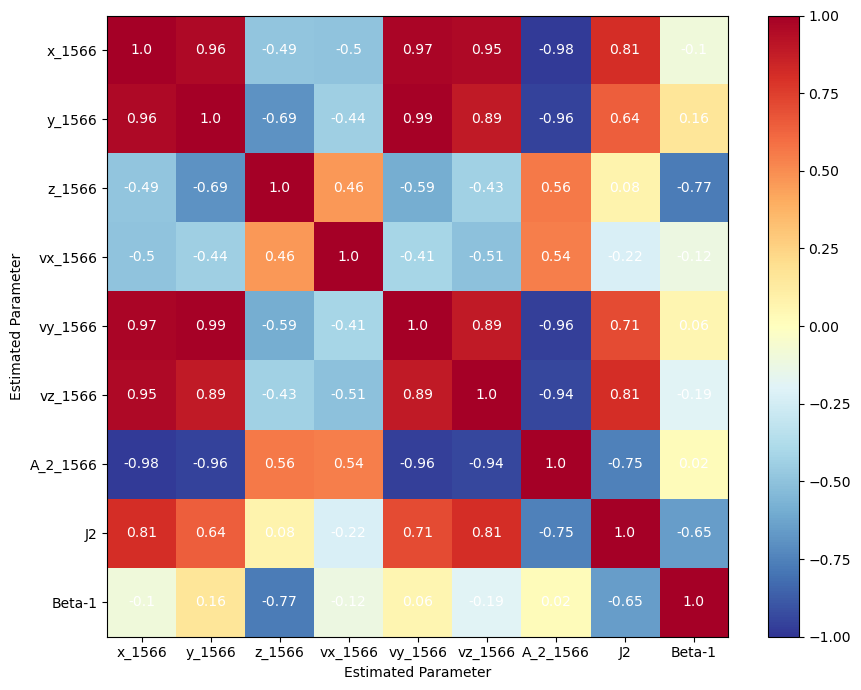

In [60]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

im = ax.imshow(correlations_occult, cmap=cm.RdYlBu_r, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)
ax.set_yticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)

# add numbers to each of the boxes
for i in range(len(estimated_param_names)):
    for j in range(len(estimated_param_names)):
        text = ax.text(
            j, i, round(correlations_occult[i, j], 2), ha="center", va="center", color="w"
        )

cb = plt.colorbar(im)

ax.set_xlabel("Estimated Parameter")
ax.set_ylabel("Estimated Parameter")

#fig.suptitle(f"Correlations for estimated parameters for {target_name}")

fig.set_tight_layout(True)

In [61]:
# covariance_output_occult.correlations
print(covariance_output_occult.covariance[-1])
print()

print("Formal errors before stellar occultations")
print(covariance_output.formal_errors)
print('---------------------------------------------')
print("Formal errors after stellar occultations")
print(covariance_output_occult.formal_errors)

diff_covariance = covariance_output.formal_errors - covariance_output_occult.formal_errors

print()
print('----------------------------------------------')
# print('Using NOISE of 1*10**3 mas')
print("Difference between formal errors before and after stellar occultations are added")
print(diff_covariance)

[-5.19833837e-04  5.38789917e-04 -1.15244748e-03 -6.22154677e-12
  1.27761054e-11 -1.85536961e-11  4.09947161e-22 -9.23202288e-09
  4.78528612e-13]

Formal errors before stellar occultations
[5.83747257e+04 3.60557397e+04 4.92079501e+04 3.69939512e-03
 6.06634705e-03 4.47469069e-03 1.41431662e-13 2.45028362e-01
 1.18256926e-05]
---------------------------------------------
Formal errors after stellar occultations
[7.55542295e+03 4.97922129e+03 2.16379679e+03 7.33106186e-05
 3.28125138e-04 1.42544098e-04 2.74916761e-14 2.05704269e-02
 6.91757625e-07]

----------------------------------------------
Difference between formal errors before and after stellar occultations are added
[5.08193027e+04 3.10765184e+04 4.70441533e+04 3.62608450e-03
 5.73822191e-03 4.33214659e-03 1.13939986e-13 2.24457935e-01
 1.11339350e-05]


Formal errors before stellar occultations
[3.14454371e+04 3.28611012e+04 3.37207414e+04 1.26533947e-03
 1.35140893e-03 1.22644945e-03 2.66144498e+04 4.26945923e+04
 1.92684696e+04 2.58940445e-02 1.78466550e-02 8.68099057e-03
 6.62914055e-02 3.30074411e-06]
---------------------------------------------
Formal errors after stellar occultations
[3.01328889e+04 3.26863534e+04 3.31896091e+04 1.21042241e-03
 1.33790970e-03 1.22568544e-03 7.98204404e+03 1.62899929e+04
 7.34497972e+03 6.11967022e-03 6.36695559e-03 2.21490558e-03
 6.21733727e-02 3.17190721e-06]

----------------------------------------------
Difference between formal errors before and after stellar occultations are added
[1.31254822e+03 1.74747797e+02 5.31132332e+02 5.49170694e-05
 1.34992239e-05 7.64007824e-07 1.86324058e+04 2.64045994e+04
 1.19234898e+04 1.97743743e-02 1.14796994e-02 6.46608499e-03
 4.11803284e-03 1.28836896e-07]

In [62]:
# [1.31549637e+03 1.75158731e+02 5.32304904e+02 5.50403646e-05
#  1.35288663e-05 7.66241425e-07 1.87688714e+04 2.65779770e+04
#  1.19875697e+04 1.99491719e-02 1.15446746e-02 6.58680505e-03
#  4.12732570e-03 1.29124590e-07]

### Mapping the formal errors over time:

In [63]:
# 1. Create the time over which you wanna see how the formal errors change
# So at J2000 I've added the stellar occultations

# simulation_start_epoch = - 10 * 365.25 * 24 *3600   # 10 years before J2000
# simulation_end_epoch = 10 * 365.25 * 24 *3600   # 10 years after J2000

simulation_start_epoch = 5 * 365.25 * 24 *3600   # J2000 + 5 years
simulation_end_epoch = 25 * 365.25 * 24 *3600   # J2000 + 25 years

output_times = np.arange(
    simulation_start_epoch,
    simulation_end_epoch,
    86400.0                 # 1 day spacing
)

In [64]:
print(covariance_output.covariance.shape)
print(len(covariance_output.formal_errors))
print(estimator.state_transition_interface)
print(estimator_stell_occult.state_transition_interface)
print(output_times.shape)
print(parameters_to_estimate.parameter_set_size)

(9, 9)
9
(7305,)
9


In [74]:
# 2. Propagation

# Propagate only the covariance with MPC observations
formal_errors_mpc = estimation_analysis.propagate_formal_errors(
    initial_covariance=covariance_output.covariance,
    state_transition_interface=estimator.state_transition_interface,
    output_times=output_times
)

# Propagate the covariance with MPC observations + stellar occultations
formal_errors_occult = estimation_analysis.propagate_formal_errors(
    initial_covariance=covariance_output_occult.covariance,
    state_transition_interface=estimator_stell_occult.state_transition_interface,
    output_times=output_times
)

print(formal_errors_mpc)
print(formal_errors_occult)

{157788000.0: array([3.58816758e+04, 6.09397944e+04, 4.73421549e+04, 6.03879665e-03,
       4.82249467e-03, 5.16710021e-03]), 157874400.0: array([3.58964001e+04, 6.12215392e+04, 4.74596295e+04, 6.11806304e-03,
       4.84831456e-03, 5.21885436e-03]), 157960800.0: array([3.59192718e+04, 6.15046699e+04, 4.75810876e+04, 6.19940606e-03,
       4.87469737e-03, 5.27184265e-03]), 158047200.0: array([3.59506516e+04, 6.17892138e+04, 4.77066635e+04, 6.28290372e-03,
       4.90164978e-03, 5.32610255e-03]), 158133600.0: array([3.59909111e+04, 6.20751983e+04, 4.78364960e+04, 6.36863799e-03,
       4.92917839e-03, 5.38167326e-03]), 158220000.0: array([3.60404332e+04, 6.23626509e+04, 4.79707280e+04, 6.45669519e-03,
       4.95728971e-03, 5.43859581e-03]), 158306400.0: array([3.60996116e+04, 6.26515994e+04, 4.81095075e+04, 6.54716604e-03,
       4.98599012e-03, 5.49691312e-03]), 158392800.0: array([3.61688518e+04, 6.29420720e+04, 4.82529871e+04, 6.64014604e-03,
       5.01528582e-03, 5.55667009e-03]),

In [66]:
# 3. Make everything into arrays

epochs = np.array(list(formal_errors_mpc.keys()))

formal_errors_mpc_array = np.array(
    list(formal_errors_mpc.values())
)

formal_errors_occult_array = np.array(
    list(formal_errors_occult.values())
)

In [67]:
print(formal_errors_mpc_array.shape)
print((formal_errors_mpc_array[0,:]))
print((formal_errors_mpc_array[-1,:]))
#list(formal_errors_mpc.values())

last_errors_i = formal_errors_mpc_array[-1,:]

(7305, 6)
[3.58816758e+04 6.09397944e+04 4.73421549e+04 6.03879665e-03
 4.82249467e-03 5.16710021e-03]
[2.48748491e+04 2.71069133e+04 2.87331910e+04 1.31181770e-03
 1.54923625e-03 1.29207071e-03]


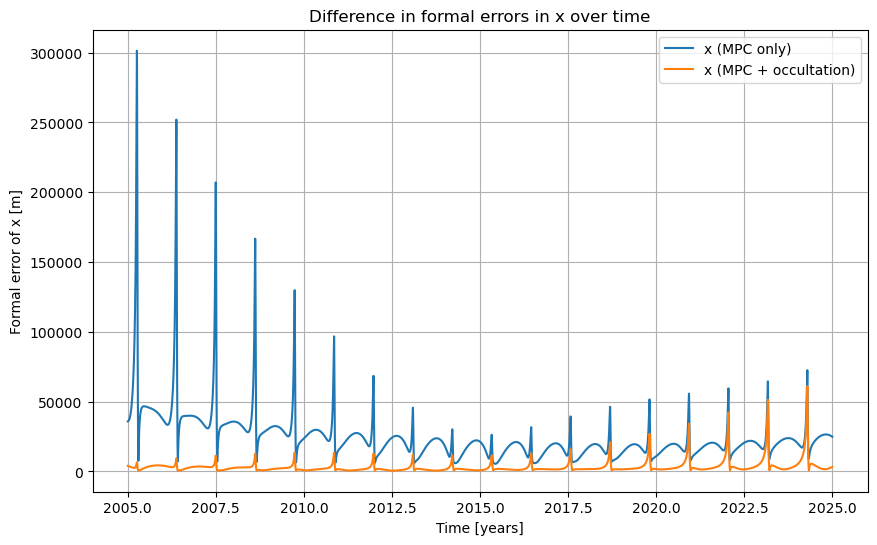

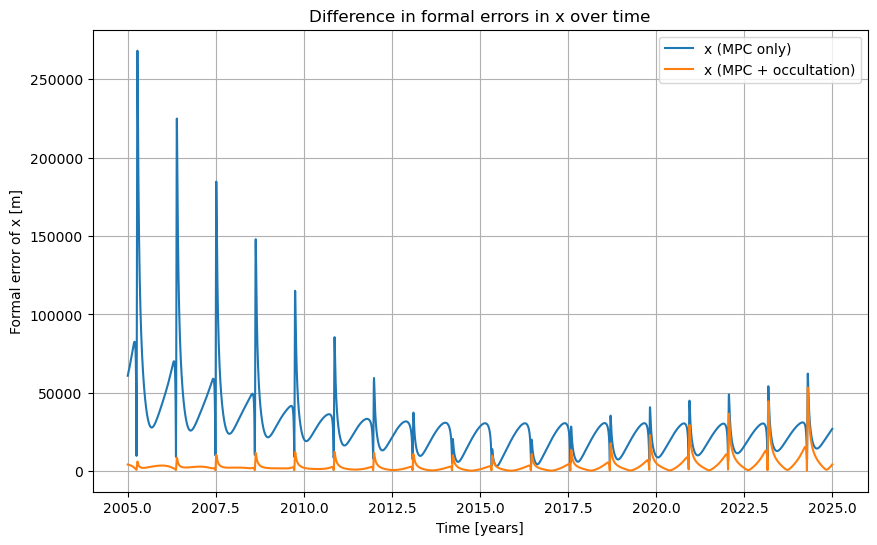

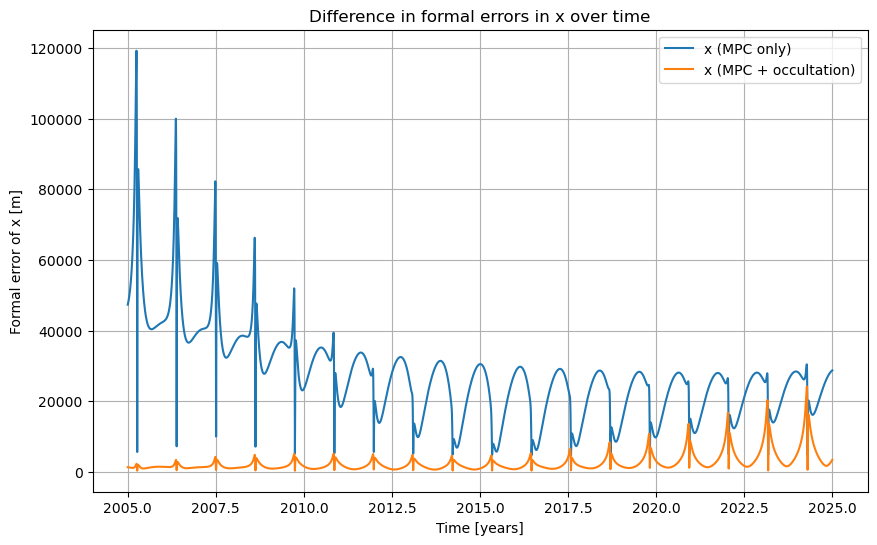

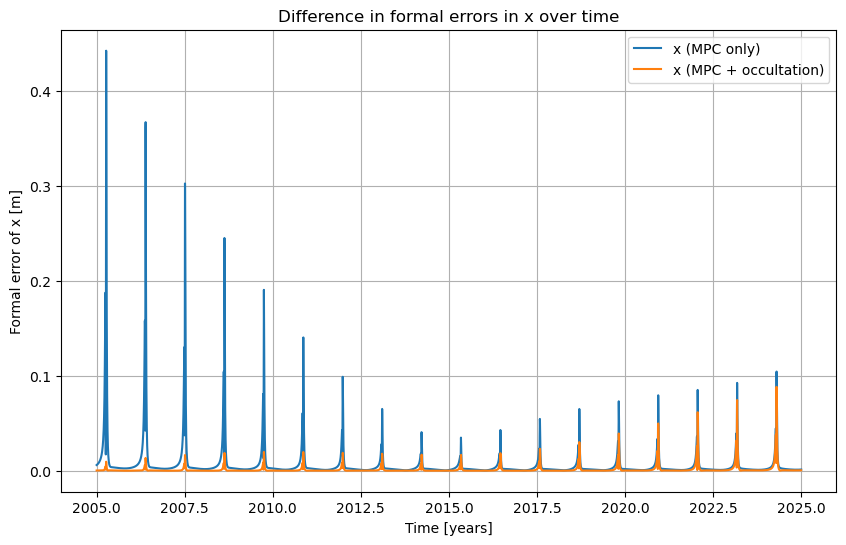

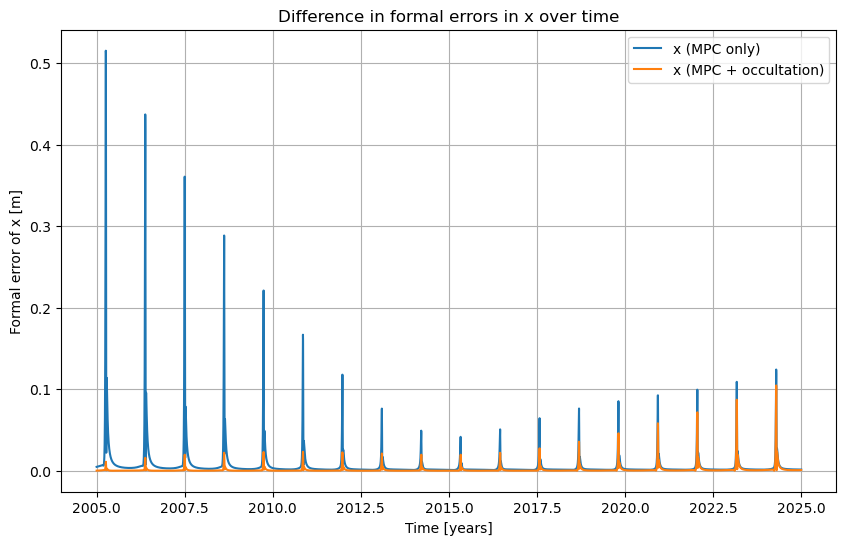

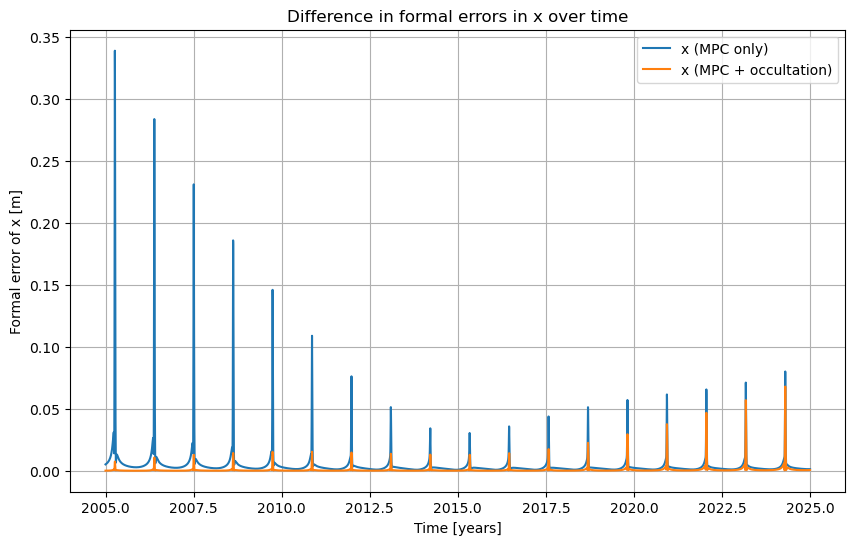

In [ ]:
for i, formal_value in enumerate(last_errors_i):

    plt.figure(figsize=(10,6))

    plt.plot(
        2000 + epochs/(365.25 * 86400.0),
        formal_errors_mpc_array[:,i],
        label="x (MPC only)"
    )

    plt.plot(
        2000 + epochs/(365.25 * 86400.0),
        formal_errors_occult_array[:,i],
        label="x (MPC + occultation)"
    )

    # Set ticks at 2000, 2002, 2004, ...
    xmin, xmax = plt.xlim()
    ticks = np.arange(np.floor(xmin/2)*2 + 2, np.ceil(xmax/2)*2, 3)

    plt.xticks(ticks, [f"{int(t)}" for t in ticks])

    plt.title(f"Difference in formal errors in x over time for {target_mpc_code[0]}")
    plt.xlabel("Time [years]")
    plt.ylabel("Formal error of x [m]")
    plt.legend()
    plt.grid()
    plt.show()

/tmp/ipykernel_10151/1572448487.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


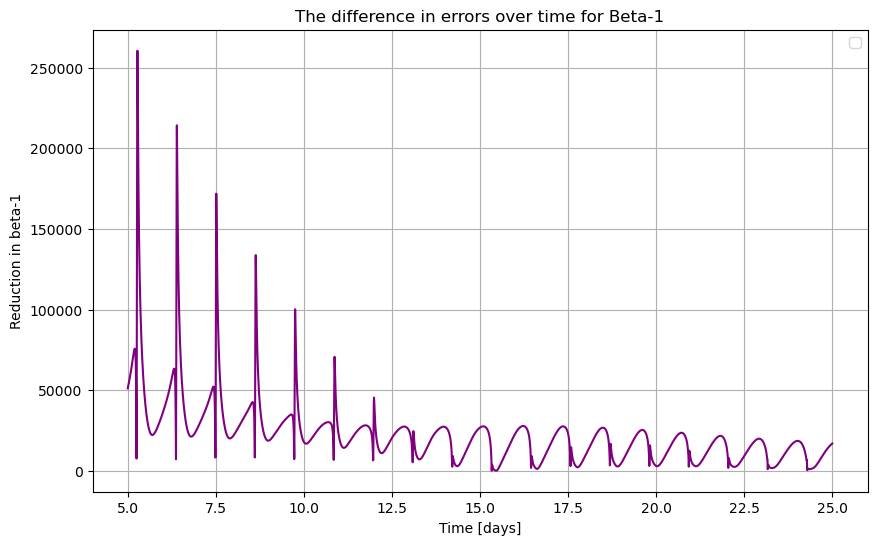

/tmp/ipykernel_10151/1572448487.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


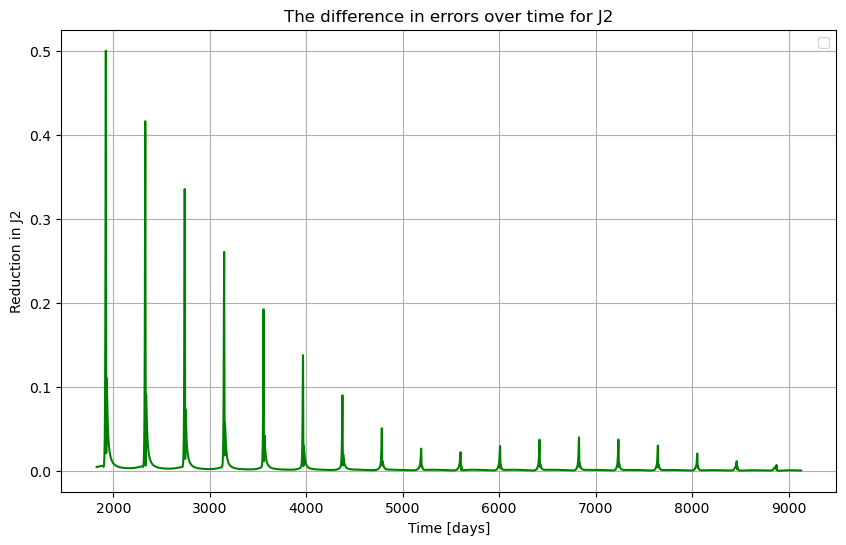

In [179]:
delta_x = (
    formal_errors_mpc_array[:,1]
    - formal_errors_occult_array[:,1]
)

delta_J2 = (
    formal_errors_mpc_array[:,-2]
    - formal_errors_occult_array[:,-2]
)

plt.figure(figsize=(10,6))

plt.plot(
    epochs/(365.25 * 86400.0),
    delta_x,
    color = 'purple'
)

# plt.axvline(18838800.0/( 365.25 * 86400.0), color='red', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.title("The difference in errors over time for Beta-1")
plt.xlabel("Time [days]")
plt.ylabel("Reduction in beta-1")
plt.grid()
plt.legend()
plt.show()


plt.figure(figsize=(10,6))

plt.plot(
    epochs/(86400.0),
    delta_J2,
    color = 'green',
)

plt.title("The difference in errors over time for J2")
plt.xlabel("Time [days]")
plt.ylabel("Reduction in J2")
plt.grid()
plt.legend()
plt.show()

In [1]:
improvement_x_2nd_asteroid = (
    100.0 *
    (
        formal_errors_mpc_array[:,1]
        - formal_errors_occult_array[:,1]
    )
    / formal_errors_mpc_array[:,1]
)

improvement_y_2nd_asteroid = (
    100.0 *
    (
        formal_errors_mpc_array[:,2]
        - formal_errors_occult_array[:,2]
    )
    / formal_errors_mpc_array[:,2]
)

improvement_z_2nd_asteroid = (
    100.0 *
    (
        formal_errors_mpc_array[:,3]
        - formal_errors_occult_array[:,3]
    )
    / formal_errors_mpc_array[:,3]
)

improvement_vx = (
    100.0 *
    (
        formal_errors_mpc_array[:,4]
        - formal_errors_occult_array[:,4]
    )
    / formal_errors_mpc_array[:,4]
)

plt.plot(2000 + epochs/(365.25 * 86400.0), improvement_x_2nd_asteroid, color = 'purple')
plt.title("The relative improvement over time for x in Percentage")
plt.xlabel("Time [years]")
plt.ylabel("Improvement in x [%]")
plt.grid()
plt.show()

plt.plot(epochs/(365.25 * 86400.0), improvement_y_2nd_asteroid, color = 'green')
plt.title("The relative improvement over time for y in Percentage")
plt.xlabel("Time [years]")
plt.ylabel("Improvement in y [%]")
plt.grid()
plt.show()

plt.plot(epochs/(365.25 * 86400.0), improvement_z_2nd_asteroid, color = 'blue')
plt.title("The relative improvement over time for x in Percentage")
plt.xlabel("Time [years]")
plt.ylabel("Improvement in z [%]")
plt.grid()
plt.show()

# plt.axvline(18838800.0/(86400.0), color='red', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.plot(
    2000 + epochs/(365.25 * 86400.0),
    improvement_vx,
    color = 'orange'
)

plt.title("The relative improvement over time for vx in Percentage")
plt.xlabel("Time [years]")
plt.ylabel("Improvement in vx [%]")
plt.grid()
plt.show()

NameError: name 'formal_errors_mpc_array' is not defined